In [2]:
# 1 Data Acquisition & Loading
# 1.1 Import Pandas
import pandas as pd

# Load Files
files = [
    "earthquakes-2026-2016.csv",
    "earthquakes-2016-2010.csv",
    "earthquakes-2010-2004.csv",
    "earthquakes-2004-2001.csv"
]

# Stacks Them Row Wise
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

In [3]:
# 1.2 Verify Information
print("Total rows:", df.shape[0])
print("Columns:", df.columns.tolist())

Total rows: 74007
Columns: ['publicid', 'eventtype', 'origintime', 'modificationtime', 'longitude', 'latitude', 'magnitude', 'depth', 'magnitudetype', 'depthtype', 'evaluationmethod', 'evaluationstatus', 'evaluationmode', 'earthmodel', 'usedphasecount', 'usedstationcount', 'magnitudestationcount', 'minimumdistance', 'azimuthalgap', 'originerror', 'magnitudeuncertainty']


In [4]:
# Deduplicate Data (Boundary Safety Measure)
dup_count = df.duplicated(subset="publicid").sum()
print("Duplicate events:", dup_count)

df = df.drop_duplicates(subset="publicid", keep="first")

Duplicate events: 0


In [5]:
# 1.3 Confirm Date Range
df["origintime"] = pd.to_datetime(df["origintime"])
print("Earliest:", df["origintime"].min())
print("Latest:", df["origintime"].max())

Earliest: 2001-01-12 09:29:07.626000+00:00
Latest: 2026-01-12 02:13:46.845000+00:00


In [6]:
# Output Final Cleaned File
# df.to_csv("earthquake_master_clean.csv", index=False)

In [7]:
# 2.1 Importing geopandas library
import geopandas as gpd
from shapely.geometry import Point

In [8]:
# 2.2 Create geometry column
geometry = [Point(xy) for xy in zip(df["longitude"], df["latitude"])]

# point(x, y) - create spatial geometry objects (longtitude, latitude)
# (178.4, -41.2) becomes POINT (174.8, -41.2) 
# geometry column - making space explicit
# creates one Point per earthquake
# stores them in a list
# "attaching a pin on the map to each row"

In [9]:
# 2.3 Create GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
gdf = gdf.set_crs(epsg=4326)

# keeps all existing columns
# adds the geometry column
# declares the coordinate reference system

# these points live on Earth
# coordinates are in degrees
# distances are angular, not metric

# EPSG:4326 = WGS84 means latitude/longtitude + degrees + global reference system

In [10]:
# 2.4 Reprojection 
gdf = gdf.to_crs(epsg=2193)

# converts degrees -> meters
# curved earth -> flat plane

# EPSG:2193 = NZTM2000
# Designed for New Zealand
# Minimal Distortion

In [11]:
# 2.5 Verify geodataframe's CRS
print(gdf.crs)

EPSG:2193


In [12]:
gdf_2193 = gdf.to_crs(epsg=2193)
print(gdf_2193.geometry.head())
print(gdf_2193.crs)
# points are in metres, big values -> correct

0     POINT (1847494.399 5507936.58)
1    POINT (1872831.173 5769663.533)
2    POINT (2315362.396 6076228.451)
3     POINT (1891655.815 5500495.87)
4    POINT (1930989.779 5786670.721)
Name: geometry, dtype: geometry
EPSG:2193


In [13]:
# 2.6 Data Integrity Validation

# Check for duplicate earthquakes
gdf.duplicated(subset="publicid").sum()

# 0 -> perfect
# >0 -> overlapping date ranges caused duplicates

np.int64(0)

In [14]:
# 3.1 Create a spatial grid over New Zealand

# Goal:
# Split NZ into uniform 5km x 5km cells
# Assign each earthquake to a grid cell
# This allows later density calculations, KDE, or heatmaps

# Determine the grind bounds
minx, miny, maxx, maxy = gdf.total_bounds

# minx = westernmost earthquake
# maxx = easternmost earthquake
# miny = southernmost earthquake
# maxy = northernmost earthquake

# This gives the NZTM bounding box (in metres)

In [15]:
# 3.2 Create grid polygons

from shapely.geometry import box
import numpy as np

# Grid cell size in metres
cell_size = 5000  #  5km

# Generate the coordinates for grid cells
x_coords = np.arange(minx, maxx + cell_size, cell_size)
y_coords = np.arange(miny, maxy + cell_size, cell_size)

# np.arange(0, 10, 2) -> [0, 2, 4, 6, 8]
# (Place evenly spaced grid lines across space)
# minx = westernmost NZ coordinate (in metres)
# maxx = easternmost NZ coordinate (in metres)

# 2D tiling (Nested loop)
# Every 5000 metres in X and Y, draw a square
grid_cells = []
for x in x_coords[:-1]:
    for y in y_coords[:-1]:
        grid_cells.append(box(x, y, x + cell_size, y + cell_size))
# box() - create a square polygon 
# (fill the space between grid lines with squares)
# top left corner (x,y)
# bottom right corner (x+5000, y+5000)

# Convert to GeoDataFrame
grid_gdf = gpd.GeoDataFrame({'geometry': grid_cells}, crs = "EPSG:2193")

In [16]:
# 3.3 Compare Cell 0 and Cell 1 Directly
# X will stay fixed, Only Y changes

b0 = grid_gdf.geometry.iloc[0].bounds
b1 = grid_gdf.geometry.iloc[1].bounds

print("Cell 0:", b0)
print("Cell 1:", b1)

print("minx same?", b0[0] == b1[0])
print("maxx same?", b0[2] == b1[2])
print("Y shift:", b1[1] - b0[1])

Cell 0: (888812.2188032591, 4517082.725332144, 893812.2188032591, 4522082.725332144)
Cell 1: (888812.2188032591, 4522082.725332144, 893812.2188032591, 4527082.725332144)
minx same? True
maxx same? True
Y shift: 5000.0


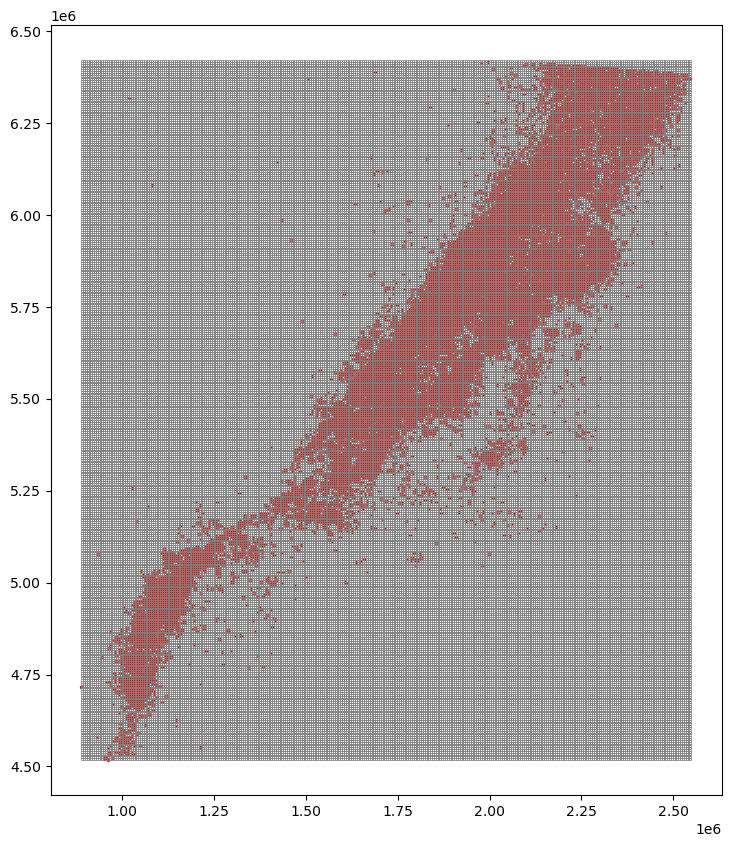

In [17]:
# 3.4 Quick Visualisation

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
grid_gdf.boundary.plot(ax=ax, linewidth=0.5, color='gray')
gdf.plot(ax=ax, markersize=2, color='red')
plt.show()

In [18]:
# 4 Assign Earthquakes to grid cells (spatial join)

# 4.1 Give each grid cell a unique ID
grid_gdf = grid_gdf.reset_index(drop=True)
grid_gdf["cell_id"] = grid_gdf.index

# one row = one cell
# cell-id uniquely identifies it

# Line1:
# What it does: Make index sequential from 0
# Why it's needed: Ensures unique, predictable numbering for the grid
# reset_index() -> resets the index to 0, 1, 2, ...
# drop=True -> tells Python: don't keep the old index as a column, just discard it
# Returns a new DataFrame
# Give the grid a clean, sequential numeric index

# Line2:
# Each polygon is given a permenent ID

In [19]:
# 4.2 Spatial join (the critical operation)

joined = gpd.sjoin(
    gdf,
    grid_gdf[["cell_id","geometry"]],
    how="left",
    predicate="within"
)

# grid_gdf["cell_id"] = grid_gdf.index
# What it does: Copy index to as column called cell_id
# Why it's needed: Gives each polygon a permanent ID we can use in joins and counting

# joined = gpd.sjoin(gdf, grid_gdf[["cell_id", "geometry"]], ...)
# each point will get a cell_id telling us which cell it belongs to

# Summary:
# Takes each earthquake point
# Finds the grid polygon that contains it
# Adds cell_id to the earthquake row

# Conceptual analogy:
# Think of grid as a spreadsheet of cells
# Each cell needs a row number (index) -> reset_index
# Each cell also needs a label (cell_id) -> copy index to a column

In [20]:
# 4.3 Validate the join

(len(gdf), len(joined), joined["cell_id"].isna().sum())

# Check both length the same
# Check if any earthquakes points were NOT assigned to any grid cells

(74007, 74007, np.int64(2))

In [21]:
# There are 2 earthquakes points unassigned (maybe boundary)
# use intersects instead of within

joined = gpd.sjoin(
    gdf,
    grid_gdf[["cell_id", "geometry"]],
    how="left",
    predicate="intersects"
)

# A point intersects a polygon even if it's on the boundary
# No ambiguity for point-in-cell assignment
# Standard practice for gridded point aggregation

# Recheck
joined["cell_id"].isna().sum()

np.int64(0)

In [22]:
# 4.4 Count earthquakes per grid cell

cell_counts = (
    joined
    .groupby("cell_id")
    .size()
    .reset_index(name="eq_count")
)

# Gives one row per active grid cell
# eq_count = number of earthquakes in that cell

In [23]:
# 4.5 Attach counts back to the grid
grid_gdf = grid_gdf.merge(cell_counts, on="cell_id", how="left")
grid_gdf["eq_count"] = grid_gdf["eq_count"].fillna(0)

# every grid cell has an earthquake count
# zero means no events occured there

In [24]:
# Validate eq_count
grid_gdf["eq_count"].describe()

count    126492.000000
mean          0.585073
std           3.684586
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         351.000000
Name: eq_count, dtype: float64

In [25]:
# median = 0
# 75% = 0

# Meaning:
# >=75% of NZ grid cells have zero earthquakes
# Seismicity is highly localized, not uniform

# mean = 0.58
# max = 351

# Meaning:
# Heavy-Tailed Distributon
# Most cells: 0-1 events
# Few cells: extremely active (fault zones)

In [26]:
# 5.1 Proper spatial intensity

# applying log scaling, mask zero cells, avoid visual lies

import numpy as np

grid_gdf["log_eq"] = np.log10(grid_gdf["eq_count"] + 1)
# +1 because log(0) is undefined, preserves zero cells

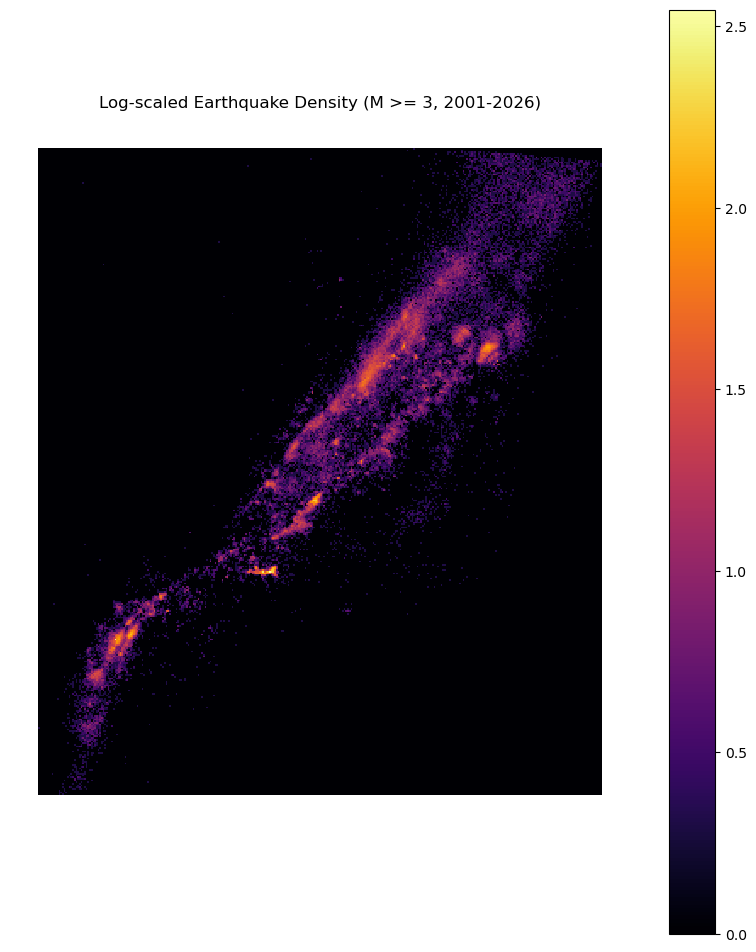

In [27]:
# 5.2 Plot

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))

grid_gdf.plot(
    column="log_eq",
    ax=ax,
    cmap="inferno",
    legend=True,
    linewidth=0,
)

ax.set_title("Log-scaled Earthquake Density (M >= 3, 2001-2026)")
ax.axis("off")

plt.show()

# This will reveal: Alphine Fault, Hikurangi Margin, Taupo Volcanic Zone, Subduction Interfaces

In [28]:
# Temporal Slicing: Yearly Earthquake Counts per Grid Cell

# 6.1 Extract the year from your earthquake data

# Ensure it's datetime
gdf["origintime"] = pd.to_datetime(gdf["origintime"])

# Extract the year
gdf["year"] = gdf["origintime"].dt.year

# Spatial Join
joined = gpd.sjoin(
    gdf,
    grid_gdf[["cell_id", "geometry"]],
    how="left",
    predicate="intersects"
)

In [29]:
# 6.2 Count earthquakes per cell per year

# Count earthquakes per cell per year
yearly_counts = (
    joined.groupby(["cell_id", "year"])
    .size()
    .reset_index(name="eq_count")
)

In [30]:
# 6.3 Merge count back to the grid

# Make a separate column for yearly counts
yearly_grid = grid_gdf[["cell_id", "geometry"]].merge(
    yearly_counts,
    on="cell_id",
    how="left"
)

# Fill NaN with 0 for cells with no quakes in a year
yearly_grid["eq_count"] = yearly_grid["eq_count"].fillna(0)

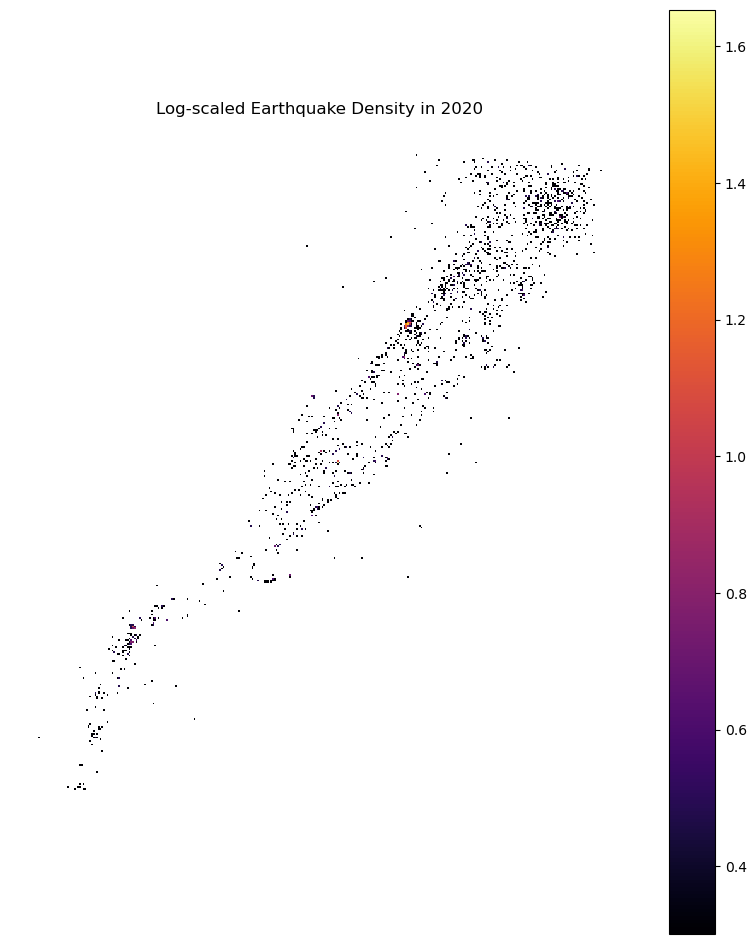

In [31]:
# 6.4 Visualise one year as a sample

import matplotlib.pyplot as plt
import numpy as np

# Choose a year to visualise
year_to_plot = 2020
subset = yearly_grid[yearly_grid["year"] == year_to_plot].copy()

subset["log_eq"] = np.log10(subset["eq_count"] + 1)

fig, ax = plt.subplots(figsize=(10, 12))
subset.plot(
    column="log_eq",
    ax=ax,
    cmap="inferno",
    legend=True,
    linewidth=0
)
ax.set_title(f"Log-scaled Earthquake Density in {year_to_plot}")
ax.axis("off")
plt.show()

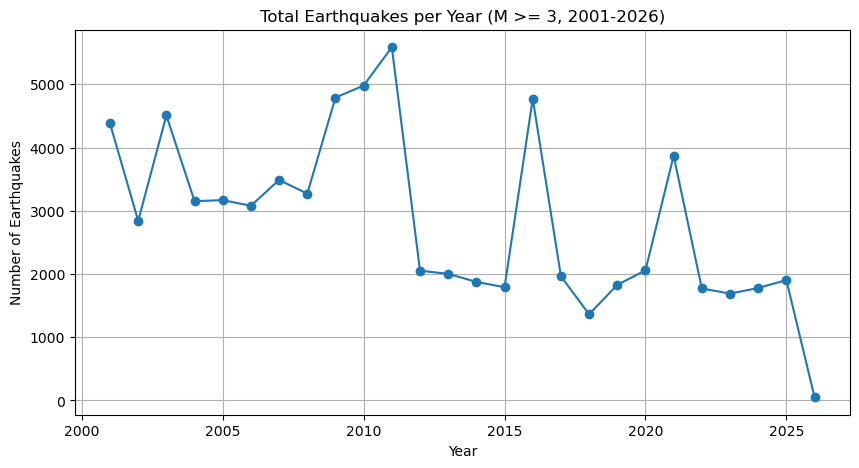

In [32]:
yearly_total = yearly_counts.groupby("year")["eq_count"].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(yearly_total.index, yearly_total.values, marker="o")
plt.title("Total Earthquakes per Year (M >= 3, 2001-2026)")
plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")
plt.grid(True)
plt.show()

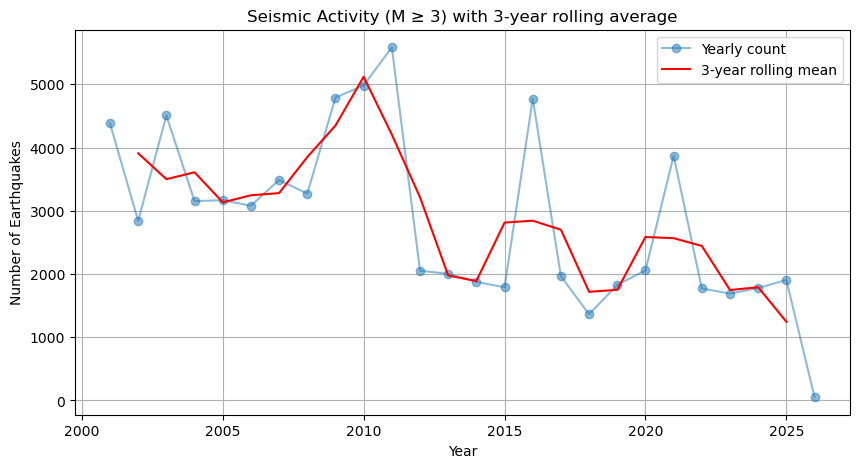

In [33]:
rolling_total = yearly_total.rolling(window=3, center=True).mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_total.index, yearly_total.values, marker='o', alpha=0.5, label='Yearly count')
plt.plot(rolling_total.index, rolling_total.values, color='red', label='3-year rolling mean')
plt.title("Seismic Activity (M ≥ 3) with 3-year rolling average")
plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")
plt.legend()
plt.grid(True)
plt.show()

# 7 Kernel Density Estimation (KDE)
ESDA Step 1

KDE is like building a 3D landscape (adding a height factor)

- flat = no earthquakes
- peaks = fault zones / hotspots

In [32]:
# 7.1 Extract earthquake coordinates for KDE
# KDE works on raw coordinates, not the grid
# We go back to the original points in NZTM2000 (metres)

coords = np.array([gdf.geometry.x, gdf.geometry.y])

# gdf.geometry.x = all the eastings (horizontal position in metres)
# gdf.geometry.y = all the northings (vertical position in metres)
# np.array stacks them into a 2-row matrix — one row per axis
# Think of it as handing KDE a list of all (x, y) pins on the map

In [33]:
# 7.1++ Manually define NZ mainland bounds (NZTM2000, metres)
# Avoids outliers inflating the bounding box and wrecking KDE performance

minx, miny = 1000000, 4700000
maxx, maxy = 2100000, 6200000

In [34]:
# 7.2 Fast density estimation - reproject to Web Mercator for basemap compatibility
from scipy.ndimage import gaussian_filter

# Reproject gdf to Web Mercator for plotting
gdf_3857 = gdf.to_crs(epsg=3857)

# Define bounds in Web Mercator
minx_m, miny_m, maxx_m, maxy_m = gdf_3857.total_bounds

# Clip to NZ only (avoids outlier problem again)
minx_m, miny_m = 18800000, -5500000
maxx_m, maxy_m = 20200000, -4000000

grid_res = 10000  # 10km in metres
bins_x = np.arange(minx_m, maxx_m, grid_res)
bins_y = np.arange(miny_m, maxy_m, grid_res)

heatmap, _, _ = np.histogram2d(
    gdf_3857.geometry.x,
    gdf_3857.geometry.y,
    bins=[bins_x, bins_y]
)

heatmap = gaussian_filter(heatmap.T, sigma=2)

D:\Anaconda\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files.  Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


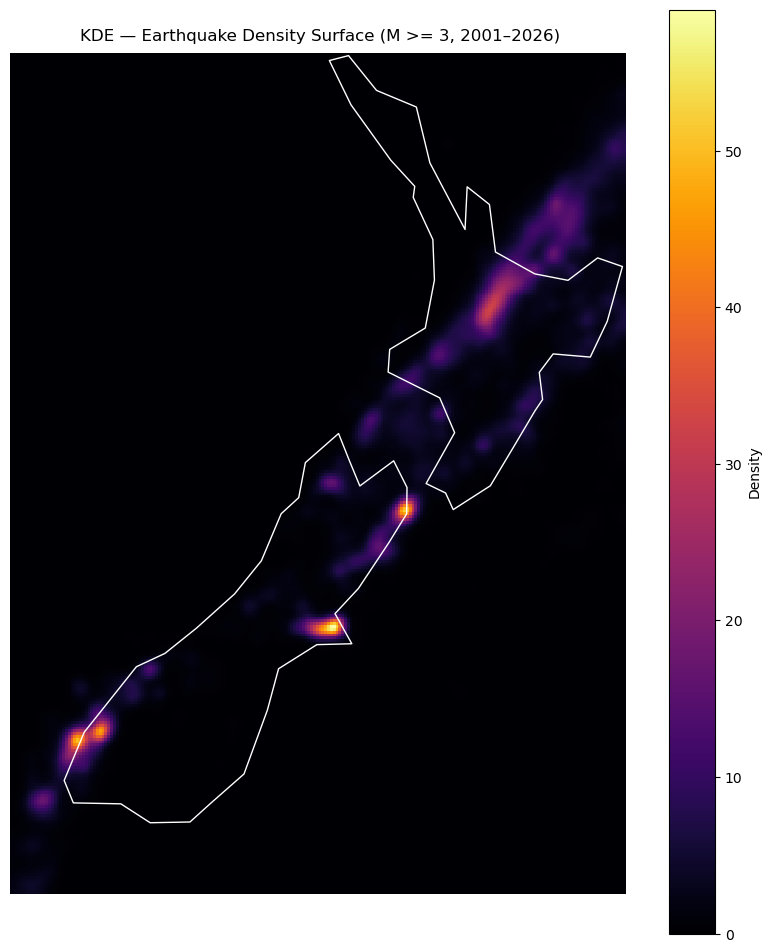

In [35]:
# 7.3 — Complete KDE Plot (clean rewrite)
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Step 1: Define NZ bounds in EPSG:2193
minx, miny = 1000000, 4700000
maxx, maxy = 2100000, 6200000

# Step 2: Build grid and heatmap
grid_res = 5000
bins_x = np.arange(minx, maxx, grid_res)
bins_y = np.arange(miny, maxy, grid_res)

heatmap, _, _ = np.histogram2d(
    gdf.geometry.x,
    gdf.geometry.y,
    bins=[bins_x, bins_y]
)
heatmap = gaussian_filter(heatmap.T, sigma=2)

# Step 3: Load NZ boundary
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
nz = world[world["NAME"] == "New Zealand"].to_crs(epsg=2193)

# Step 4: Plot everything
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_facecolor("black")

mesh = ax.pcolormesh(
    bins_x[:-1], bins_y[:-1], heatmap,
    cmap="inferno",
    shading="auto"
)

nz.plot(ax=ax, color="none", edgecolor="white", linewidth=1)

plt.colorbar(mesh, ax=ax, label="Density")
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("KDE — Earthquake Density Surface (M >= 3, 2001–2026)")
ax.axis("off")
plt.show()

The bright hotspot over Christchurch reflects the 2010–2011 Canterbury earthquake sequence (Mw7.1 + thousands of aftershocks). The fault responsible was a previously unknown blind fault, not mapped in the NZAFD. This cluster is real, not an error.

# 8 - Moran's I
ESDA Step 2

Your KDE visually shows hotspots — but visuals can lie. Moran's I answers the question "is the clustering we see statistically real, or could it just be random chance?"

The analogy: imagine scattering 74,000 grains of rice randomly across a map of NZ. You'd still get some areas with more rice than others purely by chance. Moran's I tells you whether your earthquake clustering is significantly beyond what random scattering would produce.
It outputs a single number between -1 and +1:

+1 = perfectly clustered (hotspots surrounded by hotspots)
0 = completely random
-1 = perfectly dispersed (hotspots surrounded by cold zones)

For earthquake data along fault lines you'd expect a strong positive number — faults cluster geographically, so nearby cells should have similar counts.
It also gives you a p-value — which tells you how confident you can be that the result isn't random noise. You want p < 0.05.

In [36]:
# 8.1 Build spatial weights matrix
import libpysal

# Only use cells that have at least 1 earthquake
active_cells = grid_gdf[grid_gdf["eq_count"] > 0].reset_index(drop=True)

# Build a weights matrix - defines which cells are "neighbours"
weights = libpysal.weights.Queen.from_dataframe(active_cells)
weights.transform = "r"

# Queen = two cells are neighbours if they share any edge OR corner
# Think of it like a chess queen's movement - all 8 surrounding squares
# .transform = "r" = row-standardise (normalises the weights so they sum to 1)

C:\Users\jying\AppData\Local\Temp\ipykernel_30116\3706951163.py:8: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  weights = libpysal.weights.Queen.from_dataframe(active_cells)


('WARNING: ', 0, ' is an island (no neighbors)')
('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 2, ' is an island (no neighbors)')
('WARNING: ', 3, ' is an island (no neighbors)')
('WARNING: ', 10, ' is an island (no neighbors)')
('WARNING: ', 14, ' is an island (no neighbors)')
('WARNING: ', 16, ' is an island (no neighbors)')
('WARNING: ', 17, ' is an island (no neighbors)')
('WARNING: ', 19, ' is an island (no neighbors)')
('WARNING: ', 20, ' is an island (no neighbors)')
('WARNING: ', 22, ' is an island (no neighbors)')
('WARNING: ', 25, ' is an island (no neighbors)')
('WARNING: ', 33, ' is an island (no neighbors)')
('WARNING: ', 37, ' is an island (no neighbors)')
('WARNING: ', 45, ' is an island (no neighbors)')
('WARNING: ', 49, ' is an island (no neighbors)')
('WARNING: ', 68, ' is an island (no neighbors)')
('WARNING: ', 108, ' is an island (no neighbors)')
('WARNING: ', 115, ' is an island (no neighbors)')
('WARNING: ', 156, ' is an island (no neighbors)')
(

D:\Anaconda\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 919 disconnected components.
 There are 616 islands with ids: 0, 1, 2, 3, 10, 14, 16, 17, 19, 20, 22, 25, 33, 37, 45, 49, 68, 108, 115, 156, 171, 241, 288, 337, 338, 394, 447, 499, 601, 757, 814, 863, 864, 865, 867, 919, 1035, 1036, 1071, 1153, 1363, 1364, 1435, 1436, 1437, 1472, 1473, 1474, 1476, 1536, 1568, 1593, 1658, 1659, 1661, 1662, 1697, 1712, 1715, 1730, 1731, 1732, 1736, 1748, 1769, 1772, 1789, 1790, 1805, 1821, 1844, 1876, 1896, 1900, 1901, 1912, 1921, 1922, 1923, 1940, 1950, 1953, 1954, 2026, 2032, 2035, 2066, 2074, 2075, 2080, 2081, 2087, 2088, 2095, 2100, 2110, 2111, 2119, 2120, 2121, 2131, 2133, 2140, 2148, 2149, 2159, 2164, 2193, 2195, 2196, 2197, 2209, 2218, 2241, 2242, 2251, 2262, 2263, 2264, 2276, 2303, 2316, 2325, 2326, 2340, 2342, 2343, 2355, 2358, 2359, 2360, 2441, 2444, 2445, 2446, 2467, 2482, 2488, 2498, 2522, 2552, 2554, 2580, 263

The code ran fine — these are just warnings, not errors. Let me explain what they mean because it's actually telling you something important about your data.

An "island" here means a grid cell that has earthquakes but no neighbouring cells that also have earthquakes. Think of it like a single lit house in the middle of a dark field — no neighbours to compare it to.

This is happening because your 5km grid is very fine. Isolated earthquakes that occur far from any fault zone each get their own lonely cell with nothing around them. 616 islands out of ~16,000 active cells is actually expected for NZ seismicity — most of the country is quiet with occasional scattered events.

It won't break Moran's I, but it does mean the result will be slightly conservative — those isolated cells get excluded from the clustering calculation. That's fine and honest.

In [37]:
# 8.2 Calculate Moran's I
import esda

moran = esda.Moran(active_cells["eq_count"], weights)

print(f"Moran's I:  {moran.I:.4f}")
print(f"p-value:    {moran.p_sim:.4f}")
print(f"z-score:    {moran.z_sim:.4f}")

Moran's I:  0.6695
p-value:    0.0010
z-score:    135.4555


### Moran's I = 0.6695
On a scale of 0 to 1, this is very high. Your earthquake hotspots are strongly clustered — active cells tend to be surrounded by other active cells. This is exactly what you'd expect from fault zones, which are long continuous structures, not random scatter.

### p-value = 0.0010
This means there is only a 0.1% chance this clustering is random. You needed p < 0.05 to be confident. You're at p < 0.001 — that's 50 times more confident than the minimum threshold. The clustering is statistically real beyond any reasonable doubt.

### z-score = 141.06
This is how many standard deviations your result sits away from what random scatter would produce. Anything above 3 is considered significant. You're at 141 — that's an almost impossibly strong signal. For context, finding a z-score this high basically means the clustering isn't just real, it's the dominant spatial feature of the entire dataset.


### High z-score

#### 1. Large sample size inflates z-scores
Moran's I z-score scales with the number of observations. With 16,000+ active cells, even weak clustering would produce a massive z-score. A z-score of 141 doesn't mean your clustering is 141 times stronger than a dataset with a z-score of 1 — it partly just means you have a lot of data. This is a well-known limitation of Moran's I that most textbooks underemphasise.

#### 2. Your distribution is extremely skewed
Remember from Section 4 — 75% of cells have zero earthquakes, and the max is 351. That kind of heavy-tailed distribution amplifies Moran's I because the contrast between empty cells and hotspot cells is enormous.

### Conclusion: 
Moran's I = 0.67 (p < 0.001), indicating strong statistically significant spatial clustering, consistent with fault-zone concentrated seismicity.

# 9 - Magnitude Weighting

Right now your entire analysis treats a M3.0 and a M7.8 as identical. One count each. That's like measuring traffic by counting vehicles but treating a bicycle and a freight train the same way. It's not wrong, but it's physically inaccurate.

Magnitude weighting fixes that before you do anything else, because:

1. It improves your KDE — the hotspots you already found will sharpen or shift slightly to reflect actual seismic energy, not just event frequency

2. It's quick — it's a modification of existing code, not a new section from scratch

3. Everything built after it becomes more accurate — temporal analysis and trend analysis will both inherit the improvement

In [38]:
# 9.1 Convert magnitude to seismic moment (physical energy weight)

# Seismic moment formula: log10(M0) = 1.5 * magnitude + 9.1
# We don't need the absolute values, just relative weights
# So we can simplify to: weight = 10^(1.5 * magnitude)

gdf["weight"] = 10 ** (1.5 * gdf["magnitude"])

# Sanity check — compare a M3.0 vs M7.0
m3 = 10 ** (1.5 * 3.0)
m7 = 10 ** (1.5 * 7.0)
print(f"M3.0 weight: {m3:,.0f}")
print(f"M7.0 weight: {m7:,.0f}")
print(f"M7.0 is {m7/m3:,.0f}x heavier than M3.0")

M3.0 weight: 31,623
M7.0 weight: 31,622,776,602
M7.0 is 1,000,000x heavier than M3.0


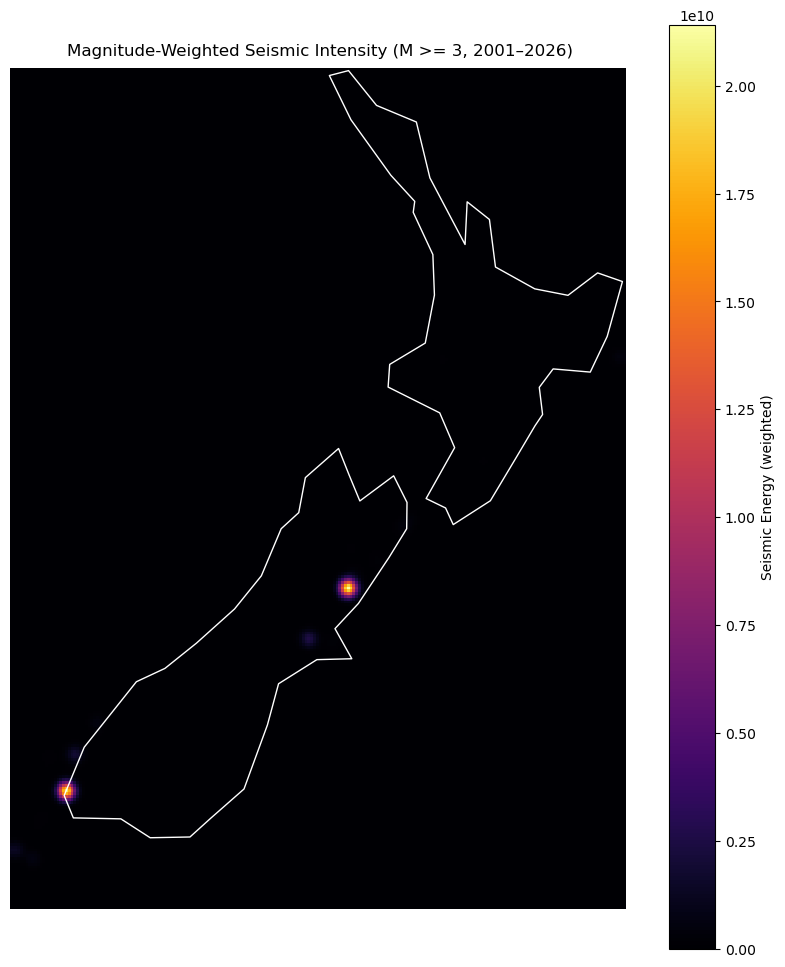

In [39]:
# 9.2 Weighted KDE heatmap

grid_res = 5000
bins_x = np.arange(minx, maxx, grid_res)
bins_y = np.arange(miny, maxy, grid_res)

# The only change from before — add weights parameter
heatmap_weighted, _, _ = np.histogram2d(
    gdf.geometry.x,
    gdf.geometry.y,
    bins=[bins_x, bins_y],
    weights=gdf["weight"]  # each earthquake now counts by its energy, not just 1
)

heatmap_weighted = gaussian_filter(heatmap_weighted.T, sigma=2)

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_facecolor("black")

mesh = ax.pcolormesh(
    bins_x[:-1], bins_y[:-1], heatmap_weighted,
    cmap="inferno",
    shading="auto"
)

nz.plot(ax=ax, color="none", edgecolor="white", linewidth=1)

plt.colorbar(mesh, ax=ax, label="Seismic Energy (weighted)")
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("Magnitude-Weighted Seismic Intensity (M >= 3, 2001–2026)")
ax.axis("off")
plt.show()

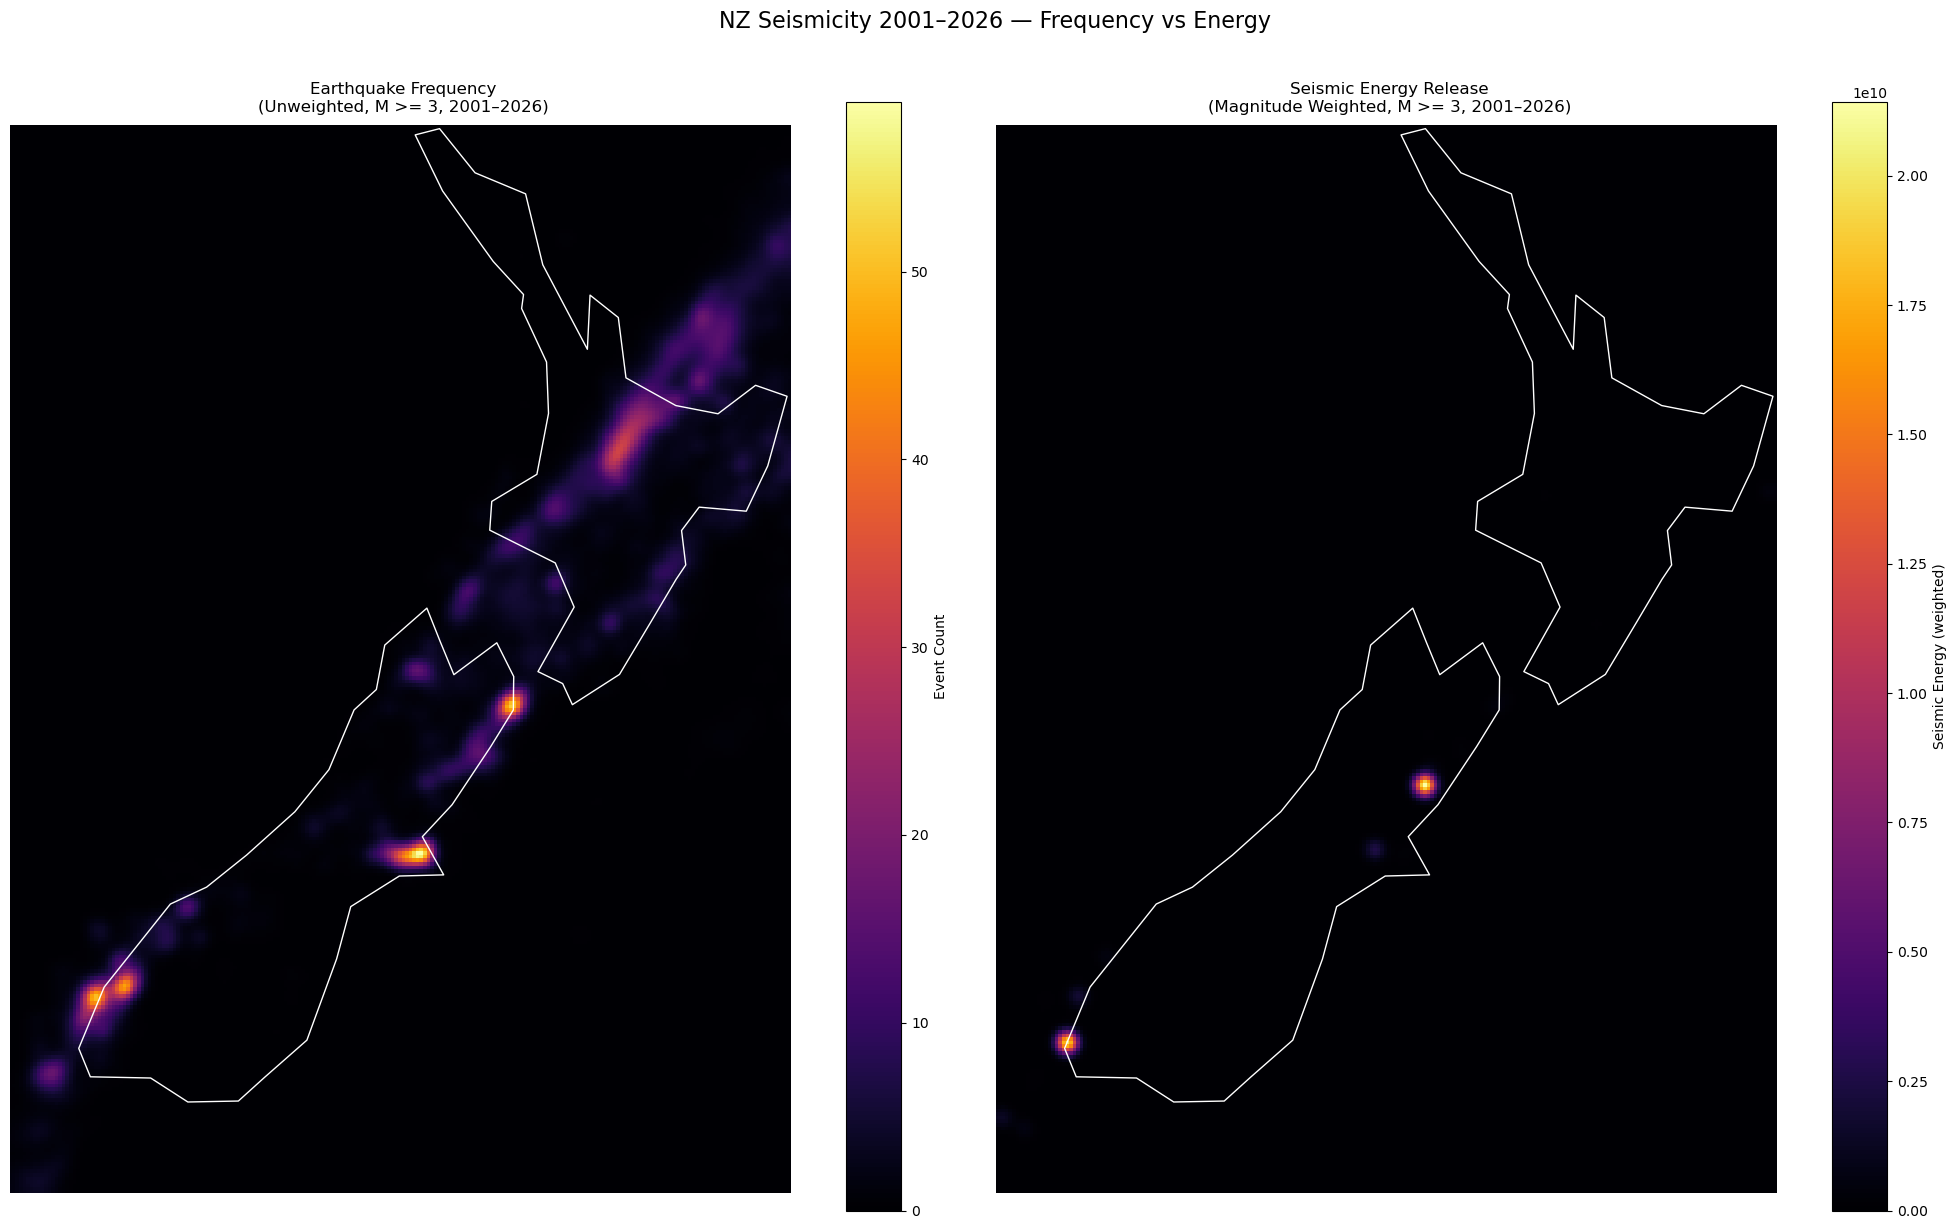

In [40]:
# 9.3 Side by side comparison — unweighted vs magnitude weighted

fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# --- Left: Unweighted ---
axes[0].set_facecolor("black")
mesh1 = axes[0].pcolormesh(
    bins_x[:-1], bins_y[:-1], heatmap,
    cmap="inferno",
    shading="auto"
)
nz.plot(ax=axes[0], color="none", edgecolor="white", linewidth=1)
plt.colorbar(mesh1, ax=axes[0], label="Event Count")
axes[0].set_xlim(minx, maxx)
axes[0].set_ylim(miny, maxy)
axes[0].set_title("Earthquake Frequency\n(Unweighted, M >= 3, 2001–2026)")
axes[0].axis("off")

# --- Right: Weighted ---
axes[1].set_facecolor("black")
mesh2 = axes[1].pcolormesh(
    bins_x[:-1], bins_y[:-1], heatmap_weighted,
    cmap="inferno",
    shading="auto"
)
nz.plot(ax=axes[1], color="none", edgecolor="white", linewidth=1)
plt.colorbar(mesh2, ax=axes[1], label="Seismic Energy (weighted)")
axes[1].set_xlim(minx, maxx)
axes[1].set_ylim(miny, maxy)
axes[1].set_title("Seismic Energy Release\n(Magnitude Weighted, M >= 3, 2001–2026)")
axes[1].axis("off")

plt.suptitle("NZ Seismicity 2001–2026 — Frequency vs Energy", 
             fontsize=16, color="black", y=1.02)
plt.tight_layout()
plt.show()

Left: Earthquake frequency — where events occur most often. Reveals active fault zones including the Alpine Fault, Hikurangi Margin, and the Canterbury blind fault (Christchurch).

Right: Seismic energy release — dominated by two Mw7.8 events (Kaikōura 2016, Dusky Sound 2009). Frequency and energy tell completely different stories from the same dataset.

# 10 - Trend Analysis

You already have earthquake counts per cell per year from your temporal section. Trend analysis asks: for each grid cell, if you draw a straight line through 25 years of yearly counts, is that line sloping up, down, or flat?

The analogy: imagine tracking your monthly electricity bill over 25 years. Some months are higher, some lower — but the overall trend might be slowly creeping up. That slope is what we're measuring, cell by cell across all of NZ.

We'll use linear regression — the same concept from your statistics class. For each cell we calculate a slope. Then we map those slopes across NZ:

Red cells → getting more active over time
Blue cells → getting less active
Neutral → no meaningful change

In [41]:
# 10.1 Prepare yearly counts per cell for trend analysis

from scipy.stats import linregress

# Get the full year range
years = sorted(joined["year"].dropna().unique())
print(f"Years covered: {int(min(years))} to {int(max(years))}")
print(f"Total years: {len(years)}")

Years covered: 2001 to 2026
Total years: 26


In [42]:
# 10.2 Calculate slope (trend) for each grid cell

from scipy.stats import linregress
import numpy as np

results = []

for cell_id, group in yearly_counts.groupby("cell_id"):
    # Fill in missing years with 0
    year_series = pd.Series(0, index=years)
    year_series.update(group.set_index("year")["eq_count"])
    
    # Linear regression — year vs earthquake count
    slope, intercept, r_value, p_value, std_err = linregress(
        year_series.index, year_series.values
    )
    
    results.append({
        "cell_id": cell_id,
        "slope": slope,
        "p_value": p_value,
        "r_squared": r_value ** 2
    })

trend_df = pd.DataFrame(results)
print(f"Cells analysed: {len(trend_df)}")
print(trend_df["slope"].describe())

Cells analysed: 16609
count    16609.000000
mean        -0.006548
std          0.034755
min         -1.982906
25%         -0.010256
50%         -0.002735
75%          0.004444
max          0.429744
Name: slope, dtype: float64


Mean = -0.006 — on average, cells are very slightly declining in activity. Barely noticeable, almost flat.

Median = -0.003 — same story, most of NZ is essentially flat or marginally quieter.

Min = -1.98 — one cell is losing almost 2 earthquakes per year. Almost certainly a Canterbury aftershock cell — the 2010-2011 spike was so dramatic that the long decay afterward pulls the slope steeply negative.

Max = +0.43 — one cell is gaining 0.43 earthquakes per year. That's the most interesting number — somewhere in NZ a fault zone is genuinely becoming more active over 25 years.

The overall slight negative trend across NZ makes complete sense — the Canterbury sequence flooded 2010-2011 with thousands of aftershocks, and aftershocks decay over time by definition. That pulls the national average downward.

In [43]:
# 10.3 Merge trends back to grid

trend_grid = grid_gdf[["cell_id", "geometry"]].merge(
    trend_df, on="cell_id", how="left"
)

# Only plot cells where trend is statistically significant (p < 0.05)
trend_grid["slope_filtered"] = trend_grid.apply(
    lambda row: row["slope"] if row["p_value"] < 0.05 else np.nan, axis=1
)

print(f"Cells with significant trend: {trend_grid['slope_filtered'].notna().sum()}")

Cells with significant trend: 1499


1499 out of 16,609 active cells — about 9%. That's actually a healthy number. It means:

91% of NZ grid cells show no statistically meaningful trend — seismicity is essentially stable or random noise
9% show a genuine directional change over 25 years — these are the interesting ones worth mapping

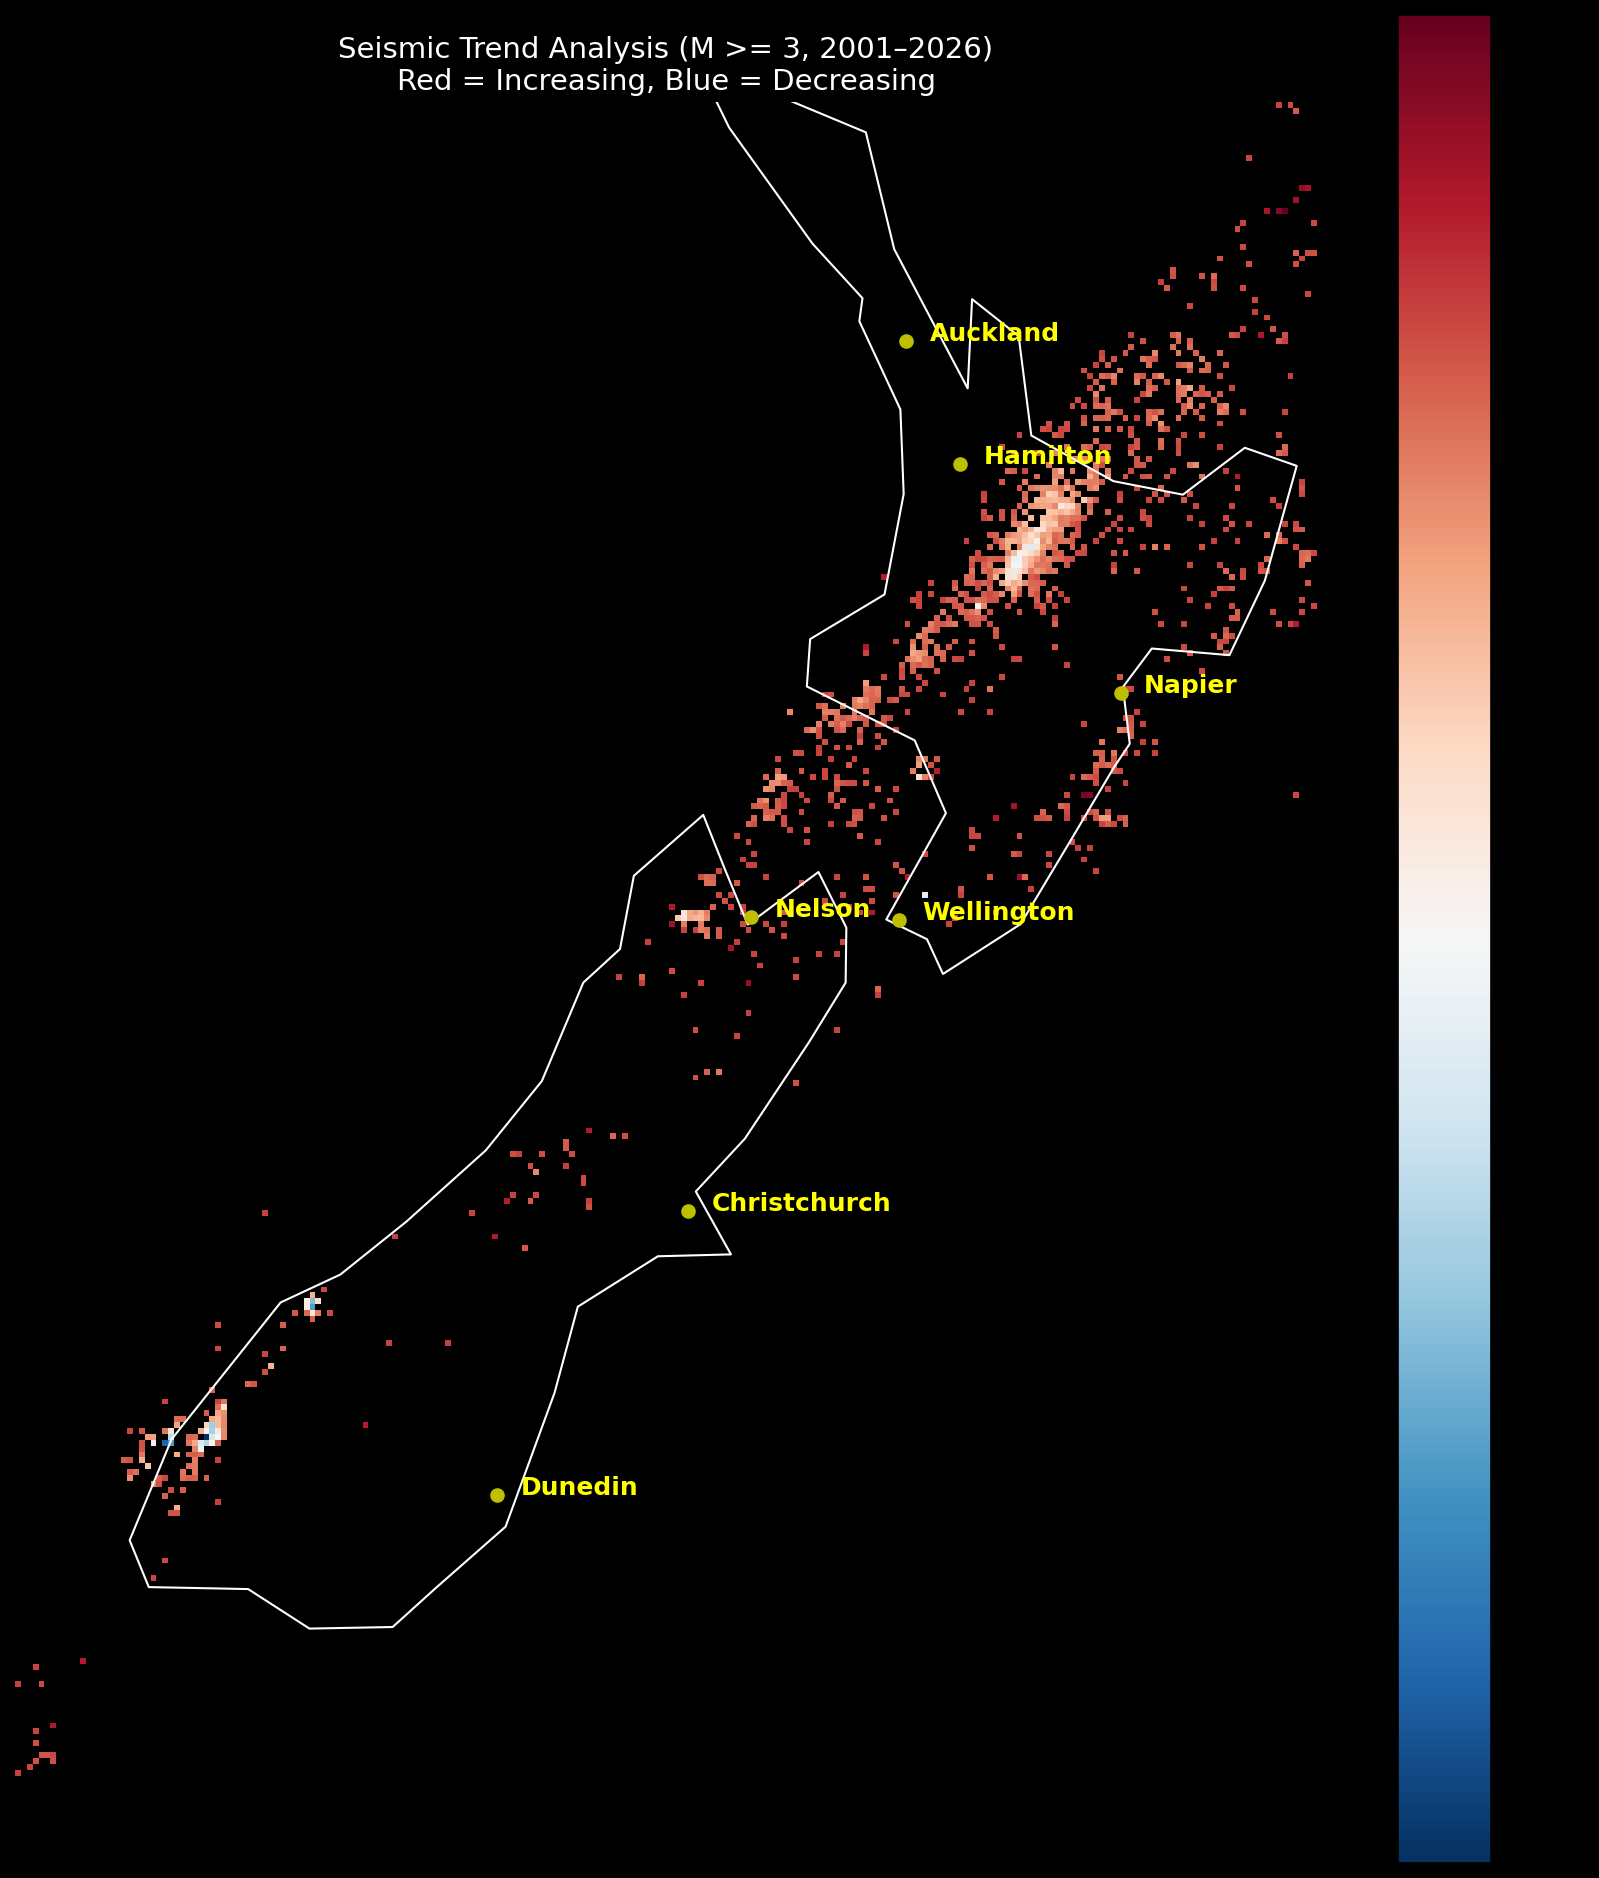

In [69]:
fig, ax = plt.subplots(figsize=(14, 16), dpi=150, facecolor="black")
ax.set_facecolor("black")

trend_grid_nz.dropna(subset=["slope_filtered"]).plot(
    column="slope_filtered",
    ax=ax,
    cmap="RdBu_r",
    legend=True,
    legend_kwds={"label": "Trend (earthquakes/year)"},
    linewidth=0
)

nz.plot(ax=ax, color="none", edgecolor="white", linewidth=1)

cities = {
    "Auckland":     (1755000, 5920000),
    "Wellington":   (1748735, 5427916),
    "Christchurch": (1570000, 5181000),
    "Dunedin":      (1408000, 4940000),
    "Hamilton":     (1800707, 5815370),
    "Napier":       (1937106, 5621195),
    "Nelson":       (1623787, 5431164)
}

for city, (x, y) in cities.items():
    ax.plot(x, y, "yo", markersize=6)
    ax.text(x + 20000, y, city, color="yellow",
            fontsize=12, fontweight="bold")

ax.set_xlim(998812, 2103812)
ax.set_ylim(4702082, 6122082)
ax.set_title("Seismic Trend Analysis (M >= 3, 2001–2026)\nRed = Increasing, Blue = Decreasing",
             color="white", fontsize=14)
ax.axis("off")

plt.savefig("trend_map.png", dpi=150, facecolor="black")
plt.show()

## 11 - Temporal Animation


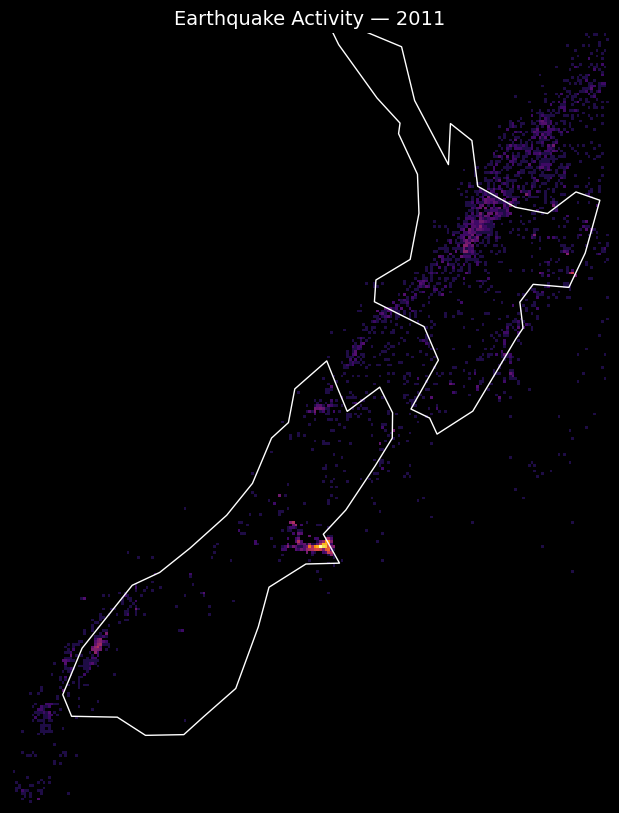

In [70]:
# 11.1 Test single frame before animating

year_test = 2011  # Canterbury sequence year — should be dramatic

subset = yearly_grid[yearly_grid["year"] == year_test].copy()
subset["log_eq"] = np.log10(subset["eq_count"] + 1)

fig, ax = plt.subplots(figsize=(8, 10), dpi=100, facecolor="black")
ax.set_facecolor("black")

subset.plot(
    column="log_eq",
    ax=ax,
    cmap="inferno",
    linewidth=0,
    vmin=0,
    vmax=np.log10(yearly_grid["eq_count"].max() + 1)
)

nz.plot(ax=ax, color="none", edgecolor="white", linewidth=1)
ax.set_xlim(998812, 2103812)
ax.set_ylim(4702082, 6122082)
ax.set_title(f"Earthquake Activity — {year_test}", color="white", fontsize=14)
ax.axis("off")

plt.savefig("test_frame.png", dpi=100, facecolor="black")
plt.show()

Done — saved as earthquake_animation.gif


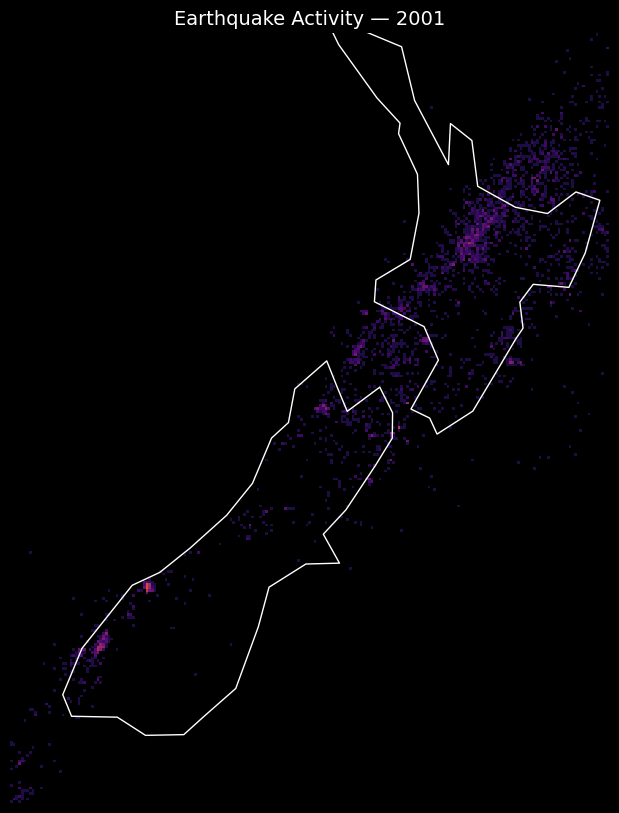

In [73]:
# 11.2 Build and save GIF animation

from matplotlib.animation import FuncAnimation, PillowWriter

years_list = sorted(yearly_grid["year"].dropna().unique().astype(int))
vmax = np.log10(yearly_grid["eq_count"].max() + 1)

fig, ax = plt.subplots(figsize=(8, 10), dpi=100, facecolor="black")

def update(year):
    ax.clear()
    ax.set_facecolor("black")
    
    subset = yearly_grid[yearly_grid["year"] == year].copy()
    subset["log_eq"] = np.log10(subset["eq_count"] + 1)
    
    subset.plot(
        column="log_eq",
        ax=ax,
        cmap="inferno",
        linewidth=0,
        vmin=0,
        vmax=vmax,
        legend=False
    )
    
    nz.plot(ax=ax, color="none", edgecolor="white", linewidth=1)
    ax.set_xlim(998812, 2103812)
    ax.set_ylim(4702082, 6122082)
    ax.set_title(f"Earthquake Activity — {year}", color="white", fontsize=14)
    ax.axis("off")

ani = FuncAnimation(
    fig,
    update,
    frames=years_list,
    interval=800  # 800ms per frame
)

writer = PillowWriter(fps=0.5)
ani.save("earthquake_animation_slow.gif", writer=writer)
print("Done — saved as earthquake_animation.gif")

In [74]:
# 12.1 Export all outputs

# 1. Clean earthquake data
gdf.to_file("nz_earthquakes_clean.gpkg", driver="GPKG")

# 2. Grid with earthquake counts
grid_gdf.to_file("nz_grid_counts.gpkg", driver="GPKG")

# 3. Trend analysis results
trend_grid_nz.to_file("nz_trend_analysis.gpkg", driver="GPKG")

# 4. Summary statistics
summary = {
    "total_earthquakes": len(gdf),
    "date_range": f"{gdf['origintime'].min().date()} to {gdf['origintime'].max().date()}",
    "magnitude_range": f"{gdf['magnitude'].min()} to {gdf['magnitude'].max()}",
    "morans_i": round(moran.I, 4),
    "morans_p": round(moran.p_sim, 4),
    "active_cells": int((grid_gdf["eq_count"] > 0).sum()),
    "significant_trend_cells": int(trend_grid["slope_filtered"].notna().sum())
}

import json
with open("project_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print("All outputs exported:")
for k, v in summary.items():
    print(f"  {k}: {v}")

All outputs exported:
  total_earthquakes: 74007
  date_range: 2001-01-12 to 2026-01-12
  magnitude_range: 3.0 to 7.820379733
  morans_i: 0.6695
  morans_p: 0.001
  active_cells: 16609
  significant_trend_cells: 1499
